In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# Configurações
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11
sns.set_palette("husl")

In [ ]:
import os
import matplotlib.pyplot as plt

# Pasta para salvar
FIGURES_DIR = "/content/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Contador
_fig_count = [0]

# Substituir plt.show ANTES de rodar qualquer coisa
_original_show = plt.show.__wrapped__ if hasattr(plt.show, '__wrapped__') else plt.show

def _auto_save_show(*args, **kwargs):
    _fig_count[0] += 1
    fig = plt.gcf()
    if fig.get_axes():  # Só salva se tem conteúdo
        fig.savefig(
            f"{FIGURES_DIR}/fig_{_fig_count[0]:03d}.png",
            dpi=150,
            bbox_inches="tight",
            facecolor="white",
        )
    _original_show(*args, **kwargs)

plt.show = _auto_save_show

print(f"✓ Configurado! Todos os gráficos serão salvos em: {FIGURES_DIR}/")
print(f"  (Agora rode o restante do notebook normalmente)")

✓ Configurado! Todos os gráficos serão salvos em: /content/figures/
  (Agora rode o restante do notebook normalmente)


In [ ]:
# ============================================================
# Carregar do Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
#
# # Ajuste o caminho abaixo conforme a localização do arquivo no seu Drive
filepath = "/content/drive/MyDrive/Case SKU/data/base-de-dados.csv"
df = pd.read_csv(filepath, thousands=".")
print(f"Dados carregados com sucesso: {df.shape[0]} linhas x {df.shape[1]} colunas")

Mounted at /content/drive
Dados carregados com sucesso: 126781 linhas x 22 colunas


## **TRATAMENTO: Converter colunas numéricas em formato object**

In [ ]:
cols_object = df.select_dtypes(include=["object"]).columns.tolist()
cols_excluir = ["sk_produto_case", "cod_canal_portfolio", "des_categoria_portfolio",
                "des_status_atual_agrup"]

for col in cols_object:
    if col not in cols_excluir:
        amostra = df[col].dropna().head(100).astype(str)
        padrao_numerico = amostra.str.match(r"^[\d\s\.\,\-\+R\$%]+$")
        if padrao_numerico.mean() > 0.7:
            serie_limpa = (
                df[col].astype(str).str.strip()
                .str.replace(".", "", regex=False)
                .str.replace(",", ".", regex=False)
            )
            df[col] = pd.to_numeric(serie_limpa, errors="coerce")

In [ ]:
# ============================================================
# PREPARAÇÃO: Eixo temporal relativo a Inatividade
# ============================================================

ciclos_ordenados = sorted(df["cod_ciclo"].unique())
mapa_ciclo = {ciclo: idx for idx, ciclo in enumerate(ciclos_ordenados)}
df["ordem_ciclo"] = df["cod_ciclo"].map(mapa_ciclo)

ultimo_ciclo_produto = (
    df.groupby("sk_produto_case")["ordem_ciclo"]
    .max()
    .reset_index(name="ordem_ultimo_ciclo")
)
df = df.merge(ultimo_ciclo_produto, on="sk_produto_case", how="left")
df["ciclos_antes_ultimo"] = df["ordem_ciclo"] - df["ordem_ultimo_ciclo"]

# Separar Ativos e Inativos
df_inativo = df[df["des_status_atual_agrup"] == "Inativo"]
df_ativo = df[df["des_status_atual_agrup"] == "Ativo"]

print(f"Produtos Inativos: {df_inativo['sk_produto_case'].nunique()}")
print(f"Produtos Ativos: {df_ativo['sk_produto_case'].nunique()}")


Produtos Inativos: 1544
Produtos Ativos: 918


In [ ]:
df

,sk_produto_case,cod_ciclo,cod_ciclo_atual,cod_ciclo_ultimo_considerado,cod_canal_portfolio,des_categoria_portfolio,des_status_atual_agrup,cod_phase_in_agrup,cod_phase_out_agrup,nr_dias_ciclo,...,tx_conversao_pdv,ind_vlr_receita_real,ind_vlr_receita_real_dia,ind_vlr_receita_real_corrigido,ind_vlr_receita_real_dia_corrigido,ind_vlr_ruptura,ind_vlr_baseline_dia_corrigido,ordem_ciclo,ordem_ultimo_ciclo,ciclos_antes_ultimo
0,1444,201803,202608,202607,VD,Perfumaria,Inativo,201708,202212,18,...,919,10125706.0,562539.0,10125706.0,562539.0,0.0,562539.0,2,80,-78
1,1299,201804,202608,202607,VD,Perfumaria,Ativo,201515,999999,21,...,162,2217164.0,1055792.0,2217164.0,1055792.0,0.0,1055792.0,3,143,-140
2,178,201807,202608,202607,Geral,Perfumaria,Inativo,201705,201916,17,...,648,3673927.0,216113.0,3673927.0,216113.0,0.0,13486.0,6,33,-27
3,1267,201814,202608,202607,VD,Perfumaria,Ativo,201713,202717,21,...,1105,154071758.0,7336751.0,154071758.0,7336751.0,0.0,1946058.0,13,143,-130
4,515,201809,202608,202607,Geral,Corpo e Banho,Inativo,201614,202215,16,...,392,1899236.0,118702.0,1899236.0,118702.0,0.0,177185.0,8,83,-75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126776,1911,202607,202608,202607,VD,Perfumaria,Ativo,202201,999999,14,...,247,24273021.0,1733787.0,25177847.0,1798417.0,9048260.0,1798417.0,143,143,0
126777,2119,202607,202608,202607,VD,Corpo e Banho,Ativo,202402,202717,14,...,723,275714.0,19694.0,3681.0,26293.0,923860.0,5788.0,143,143,0
126778,2379,202607,202608,202607,VD,Corpo e Banho,Ativo,202515,999999,14,...,623,577094.0,41221.0,1292567.0,92326.0,7154730.0,92326.0,143,143,0
126779,842,202607,202608,202607,Geral,Corpo e Banho,Ativo,202312,202717,14,...,1501,1608667.0,114905.0,3278299.0,234164.0,16696320.0,219061.0,143,143,0


## 1: PADRÕES DE VENDAS QUE PRECEDEM O DECLÍNIO

1.1 TRAJETÓRIA DE RECEITA ANTES DA INATIVAÇÃO


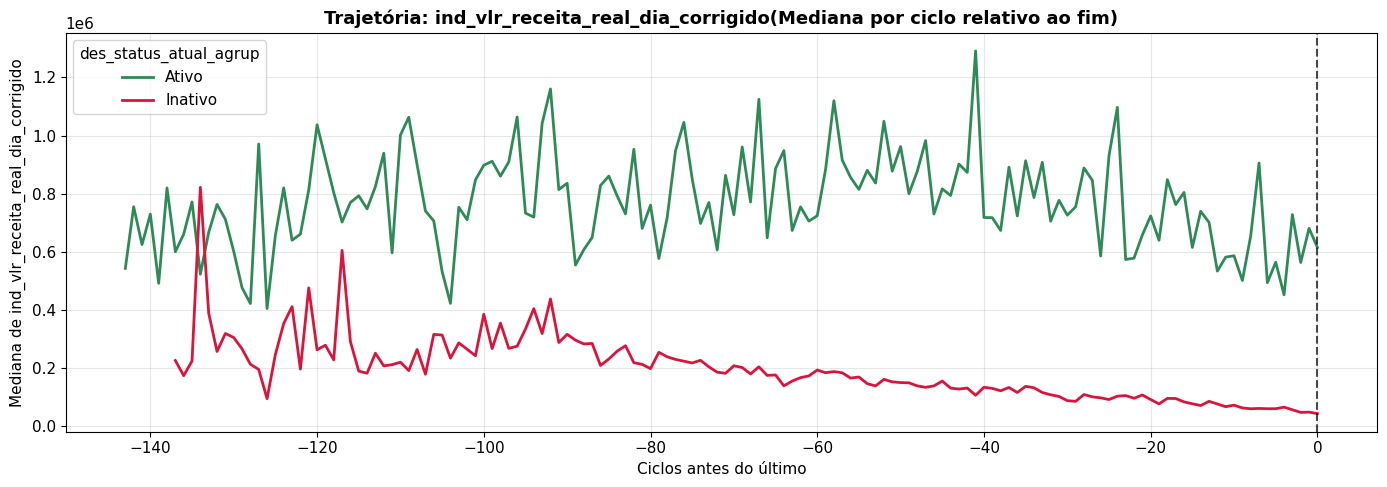

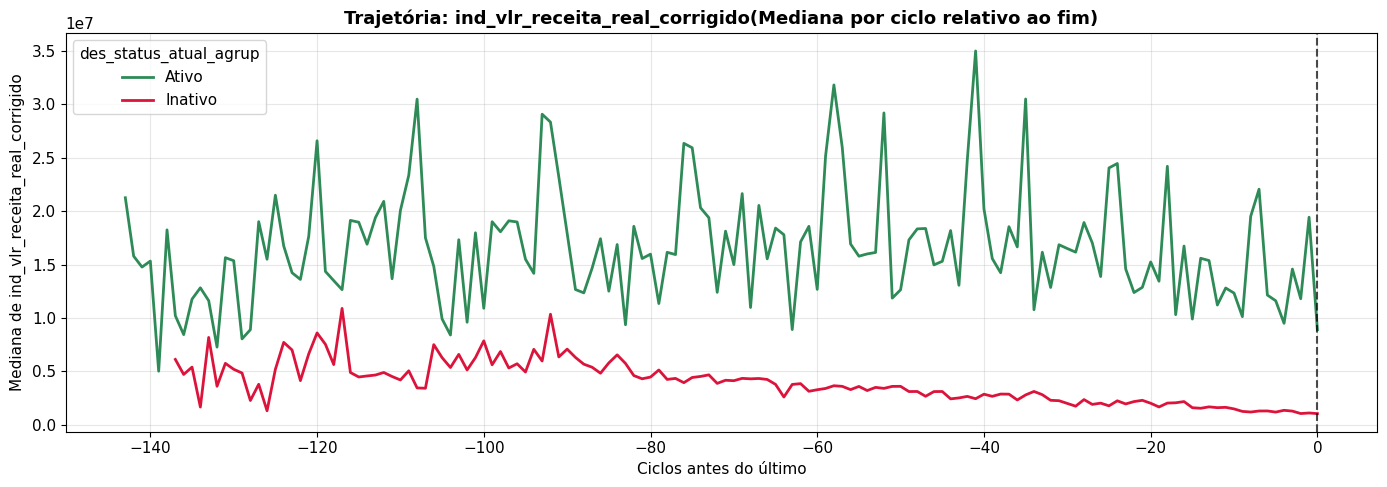

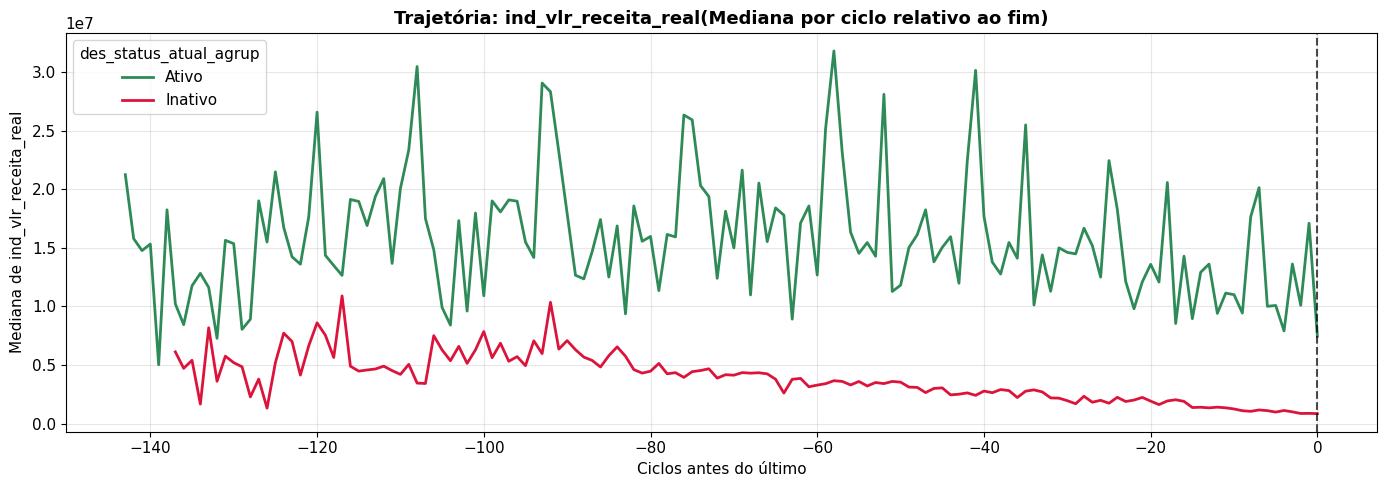

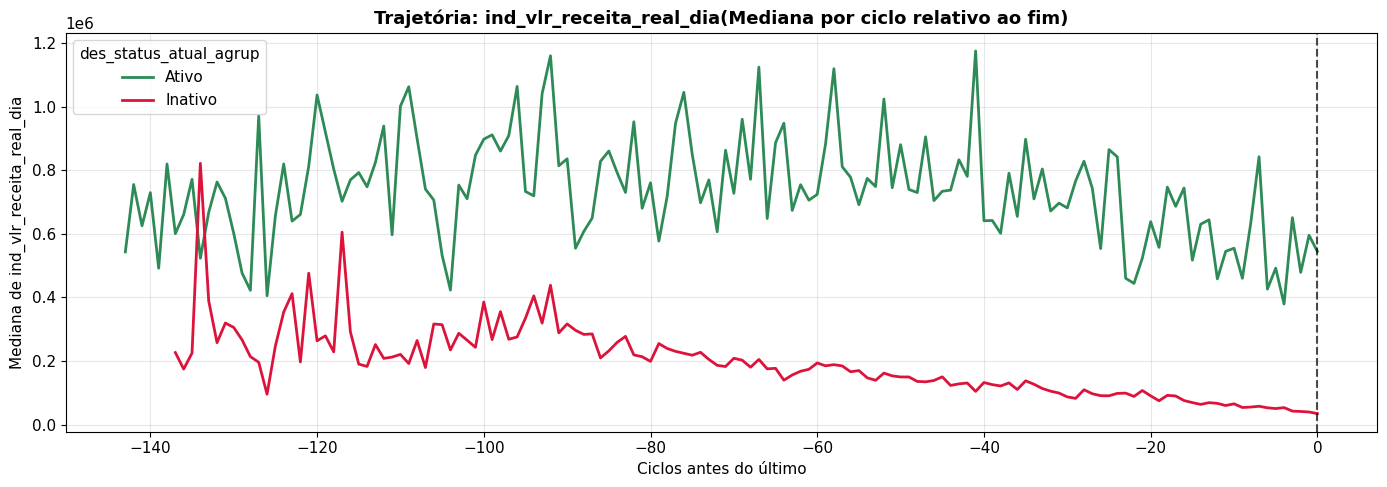

In [ ]:
# ----------------------------------------------------------
# 1.1 Trajetória de receita antes da inativação
# ----------------------------------------------------------

print(f"{'='*60}")
print("1.1 TRAJETÓRIA DE RECEITA ANTES DA INATIVAÇÃO")
print(f"{'='*60}")

vars_vendas = [
    "ind_vlr_receita_real_dia_corrigido",
    "ind_vlr_receita_real_corrigido",
    "ind_vlr_receita_real",
    "ind_vlr_receita_real_dia",
]
vars_vendas = [v for v in vars_vendas if v in df.columns]

# Comparação Ativos vs Inativos
for var in vars_vendas:
    traj = (
        df.groupby(["des_status_atual_agrup", "ciclos_antes_ultimo"])[var]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(14, 5))
    sns.lineplot(
        data=traj,
        x="ciclos_antes_ultimo",
        y=var,
        hue="des_status_atual_agrup",
        palette={"Ativo": "seagreen", "Inativo": "crimson"},
        linewidth=2,
    )
    plt.axvline(0, linestyle="--", color="black", alpha=0.7)
    plt.title(f"Trajetória: {var}(Mediana por ciclo relativo ao fim)", fontsize=13, fontweight="bold")
    plt.xlabel("Ciclos antes do último")
    plt.ylabel(f"Mediana de {var}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


1.2 VELOCIDADE DA QUEDA - JANELAS TEMPORAIS


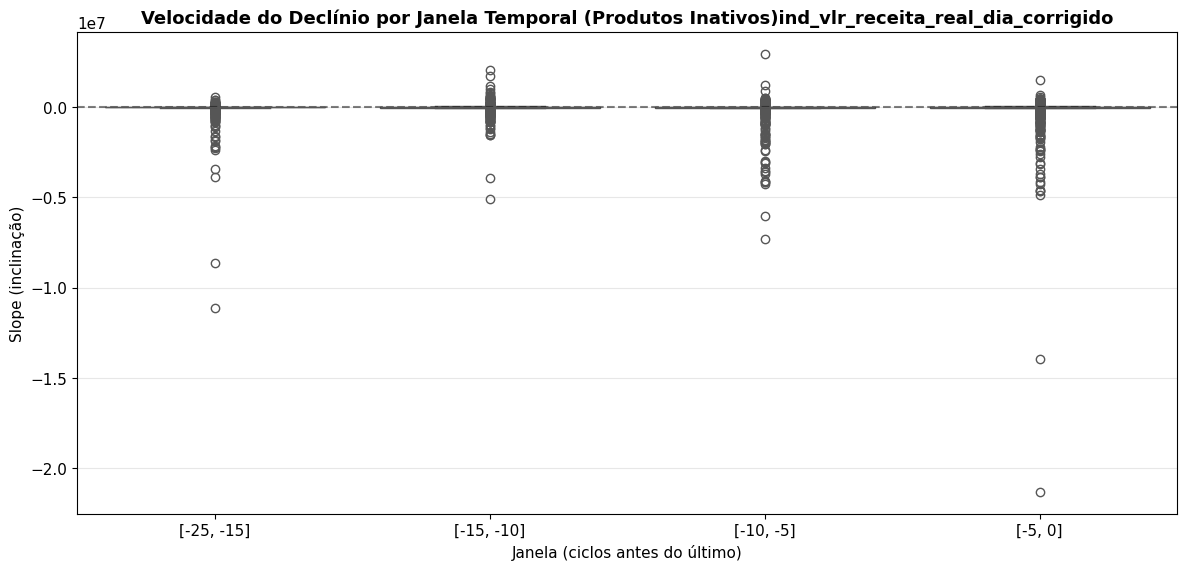

INSIGHT: A queda se acelera nos últimos 5 ciclos?
  Janela [-25, -15]: slope mediano = -578.954545
  Janela [-15, -10]: slope mediano = -438.528571
  Janela [-10, -5]: slope mediano = -1527.442857
  Janela [-5, 0]: slope mediano = -614.014286


In [ ]:
# ----------------------------------------------------------
# 1.2 Velocidade da queda de vendas (slope por janela)
# ----------------------------------------------------------

print(f"{'='*60}")
print("1.2 VELOCIDADE DA QUEDA - JANELAS TEMPORAIS")
print(f"{'='*60}")

var_principal = "ind_vlr_receita_real_dia_corrigido"

def calcular_slope_janela(grupo, var, janela_inicio, janela_fim):
    """Calcula slope dentro de uma janela de ciclos relativos."""
    dados = grupo[(grupo["ciclos_antes_ultimo"] >= janela_inicio) &
                  (grupo["ciclos_antes_ultimo"] <= janela_fim)]
    if len(dados) < 3:
        return np.nan
    x = dados["ciclos_antes_ultimo"].values
    y = dados[var].values
    mask = ~np.isnan(y)
    if mask.sum() < 3:
        return np.nan
    slope, _, _, _, _ = stats.linregress(x[mask], y[mask])
    return slope

# Calcular slope em diferentes janelas para Inativos
janelas = [(-25, -15), (-15, -10), (-10, -5), (-5, 0)]

slopes_por_janela = []
for produto in df_inativo["sk_produto_case"].unique():
    dados_prod = df_inativo[df_inativo["sk_produto_case"] == produto]
    for j_inicio, j_fim in janelas:
        slope = calcular_slope_janela(dados_prod, var_principal, j_inicio, j_fim)
        slopes_por_janela.append({
            "sk_produto_case": produto,
            "janela": f"[{j_inicio}, {j_fim}]",
            "slope": slope,
        })

df_slopes = pd.DataFrame(slopes_por_janela)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_slopes,
    x="janela",
    y="slope",
    palette="RdYlGn_r",
)
plt.axhline(0, linestyle="--", color="black", alpha=0.5)
plt.title(
    f"Velocidade do Declínio por Janela Temporal (Produtos Inativos){var_principal}",
    fontsize=13, fontweight="bold",
)
plt.xlabel("Janela (ciclos antes do último)")
plt.ylabel("Slope (inclinação)")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("INSIGHT: A queda se acelera nos últimos 5 ciclos?")
for j_inicio, j_fim in janelas:
    slope_mediano = df_slopes[df_slopes["janela"] == f"[{j_inicio}, {j_fim}]"]["slope"].median()
    print(f"  Janela [{j_inicio}, {j_fim}]: slope mediano = {slope_mediano:.6f}")

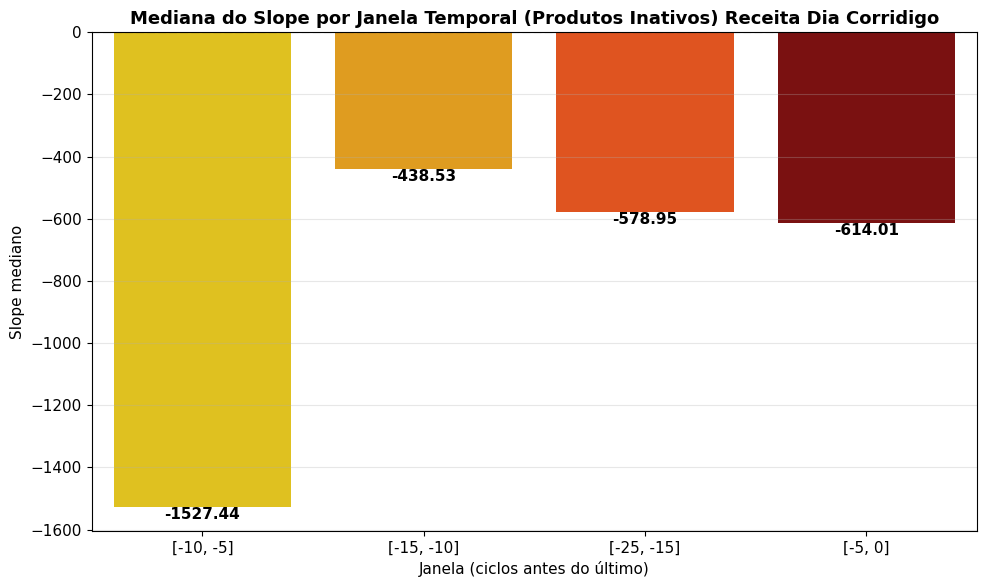

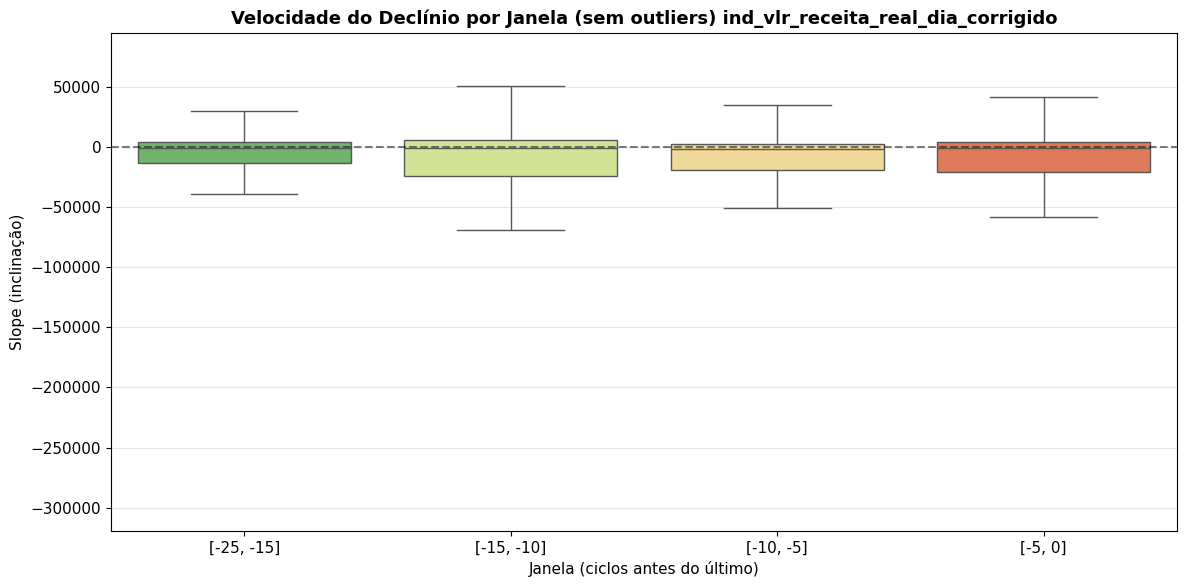

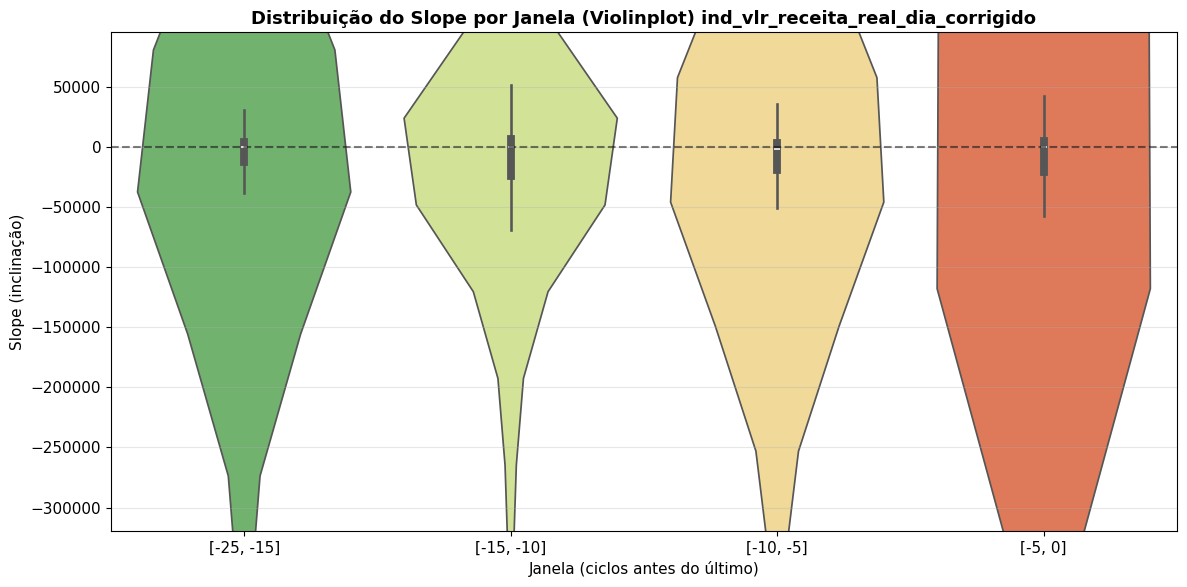

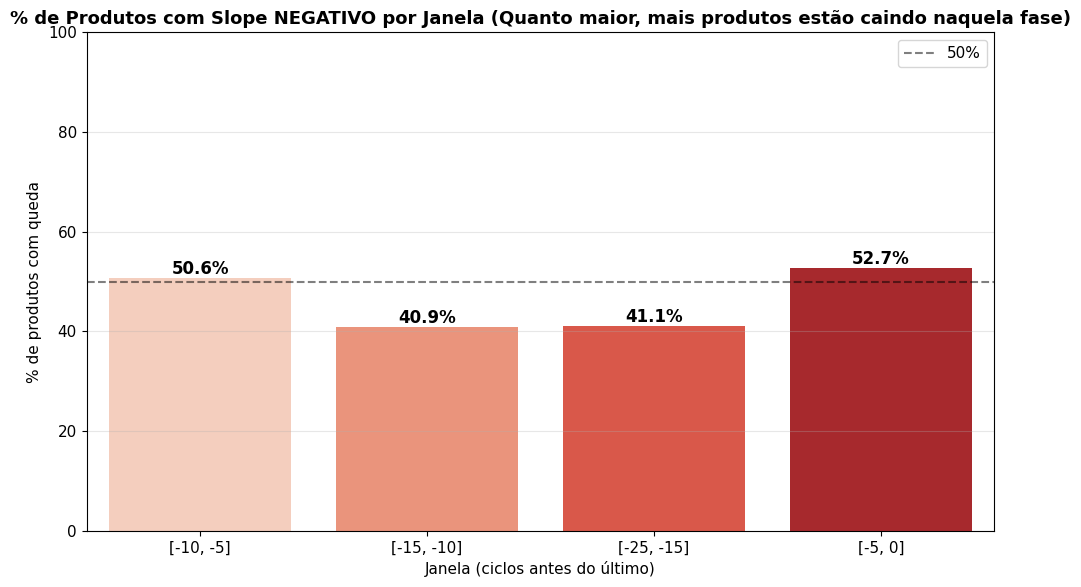

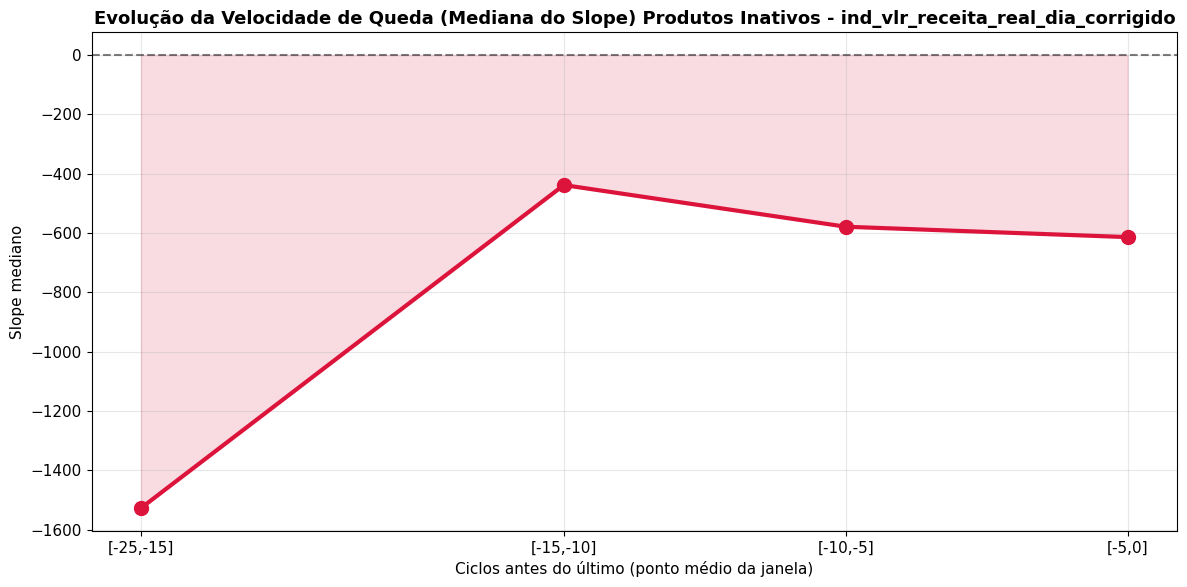

RESUMO: VELOCIDADE DO DECLÍNIO POR JANELA
Janela          Mediana Slope      % com queda    
------------------------------------------------
[-10, -5]       -1527.4429         50.6%
[-15, -10]      -438.5286          40.9%
[-25, -15]      -578.9545          41.1%
[-5, 0]         -614.0143          52.7%
INTERPRETAÇÃO:
  - Se slope mediano fica mais negativo nas janelas finais → queda ACELERA
  - Se % de produtos com queda aumenta → mais SKUs entram em declínio
  - Janela [-5, 0] vs [-25, -15]: mostra se o declínio é súbito ou gradual



In [ ]:
# ============================================================
# VELOCIDADE DA QUEDA - VISUALIZAÇÕES MELHORADAS
# ============================================================

# Usar os mesmos dados já calculados (df_slopes)

# ============================================================
# 1. BARPLOT DA MEDIANA (mais claro que boxplot)
# ============================================================

mediana_por_janela = df_slopes.groupby("janela")["slope"].median().reset_index()

plt.figure(figsize=(10, 6))
cores = ["gold", "orange", "orangered", "darkred"]
sns.barplot(
    data=mediana_por_janela,
    x="janela",
    y="slope",
    palette=cores,
)
plt.axhline(0, linestyle="--", color="black", alpha=0.5)
plt.title("Mediana do Slope por Janela Temporal (Produtos Inativos) Receita Dia Corridigo", fontsize=13, fontweight="bold")
plt.xlabel("Janela (ciclos antes do último)")
plt.ylabel("Slope mediano")
plt.grid(True, alpha=0.3, axis="y")

# Anotar valores
for i, row in mediana_por_janela.iterrows():
    plt.annotate(f"{row['slope']:.2f}", xy=(i, row['slope']),
                 ha='center', va='bottom' if row['slope'] >= 0 else 'top',
                 fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 2. BOXPLOT SEM OUTLIERS (fliersize=0 + limite no eixo Y)
# ============================================================

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_slopes,
    x="janela",
    y="slope",
    palette="RdYlGn_r",
    fliersize=0,  # Remove os outliers visuais
)
plt.axhline(0, linestyle="--", color="black", alpha=0.5)

# Limitar eixo Y aos percentis 5-95 para focar no comportamento central
p5 = df_slopes["slope"].quantile(0.05)
p95 = df_slopes["slope"].quantile(0.95)
plt.ylim(p5, p95)

plt.title("Velocidade do Declínio por Janela (sem outliers) ind_vlr_receita_real_dia_corrigido", fontsize=13, fontweight="bold")
plt.xlabel("Janela (ciclos antes do último)")
plt.ylabel("Slope (inclinação)")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ============================================================
# 3. VIOLINPLOT (mostra a distribuição inteira)
# ============================================================

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_slopes,
    x="janela",
    y="slope",
    palette="RdYlGn_r",
    inner="box",
    cut=0,
)
plt.axhline(0, linestyle="--", color="black", alpha=0.5)
plt.ylim(p5, p95)
plt.title("Distribuição do Slope por Janela (Violinplot) ind_vlr_receita_real_dia_corrigido", fontsize=13, fontweight="bold")
plt.xlabel("Janela (ciclos antes do último)")
plt.ylabel("Slope (inclinação)")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ============================================================
# 4. PROPORÇÃO DE SLOPES NEGATIVOS (mais intuitivo para negócio)
# ============================================================

prop_negativo = (
    df_slopes.groupby("janela")["slope"]
    .apply(lambda x: (x < 0).mean() * 100)
    .reset_index(name="pct_negativo")
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=prop_negativo,
    x="janela",
    y="pct_negativo",
    palette="Reds",
)
plt.axhline(50, linestyle="--", color="black", alpha=0.5, label="50%")
plt.title("% de Produtos com Slope NEGATIVO por Janela (Quanto maior, mais produtos estão caindo naquela fase)", fontsize=13, fontweight="bold")
plt.xlabel("Janela (ciclos antes do último)")
plt.ylabel("% de produtos com queda")
plt.legend()
plt.grid(True, alpha=0.3, axis="y")
plt.ylim(0, 100)

for i, row in prop_negativo.iterrows():
    plt.annotate(f"{row['pct_negativo']:.1f}%", xy=(i, row['pct_negativo']),
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 5. LINEPLOT - EVOLUÇÃO DA MEDIANA DO SLOPE
# ============================================================

mediana_por_janela["janela_num"] = [-20, -12.5, -7.5, -2.5]  # Ponto médio de cada janela

plt.figure(figsize=(12, 6))
plt.plot(
    mediana_por_janela["janela_num"],
    mediana_por_janela["slope"],
    marker="o",
    markersize=10,
    linewidth=3,
    color="crimson",
)
plt.axhline(0, linestyle="--", color="black", alpha=0.5)
plt.fill_between(
    mediana_por_janela["janela_num"],
    mediana_por_janela["slope"],
    0,
    alpha=0.15,
    color="crimson",
)
plt.title("Evolução da Velocidade de Queda (Mediana do Slope) Produtos Inativos - ind_vlr_receita_real_dia_corrigido", fontsize=13, fontweight="bold")
plt.xlabel("Ciclos antes do último (ponto médio da janela)")
plt.ylabel("Slope mediano")
plt.xticks(mediana_por_janela["janela_num"], ["[-25,-15]", "[-15,-10]", "[-10,-5]", "[-5,0]"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# RESUMO
# ============================================================

print(f"{'='*60}")
print("RESUMO: VELOCIDADE DO DECLÍNIO POR JANELA")
print(f"{'='*60}")
print(f"{'Janela':<15} {'Mediana Slope':<18} {'% com queda':<15}")
print(f"{'-'*48}")
for i, row in mediana_por_janela.iterrows():
    pct = prop_negativo.iloc[i]["pct_negativo"]
    print(f"{row['janela']:<15} {row['slope']:<18.4f} {pct:.1f}%")

print(f"""INTERPRETAÇÃO:
  - Se slope mediano fica mais negativo nas janelas finais → queda ACELERA
  - Se % de produtos com queda aumenta → mais SKUs entram em declínio
  - Janela [-5, 0] vs [-25, -15]: mostra se o declínio é súbito ou gradual
""")


1.3 DELTA DE PERFORMANCE (Real - Baseline)


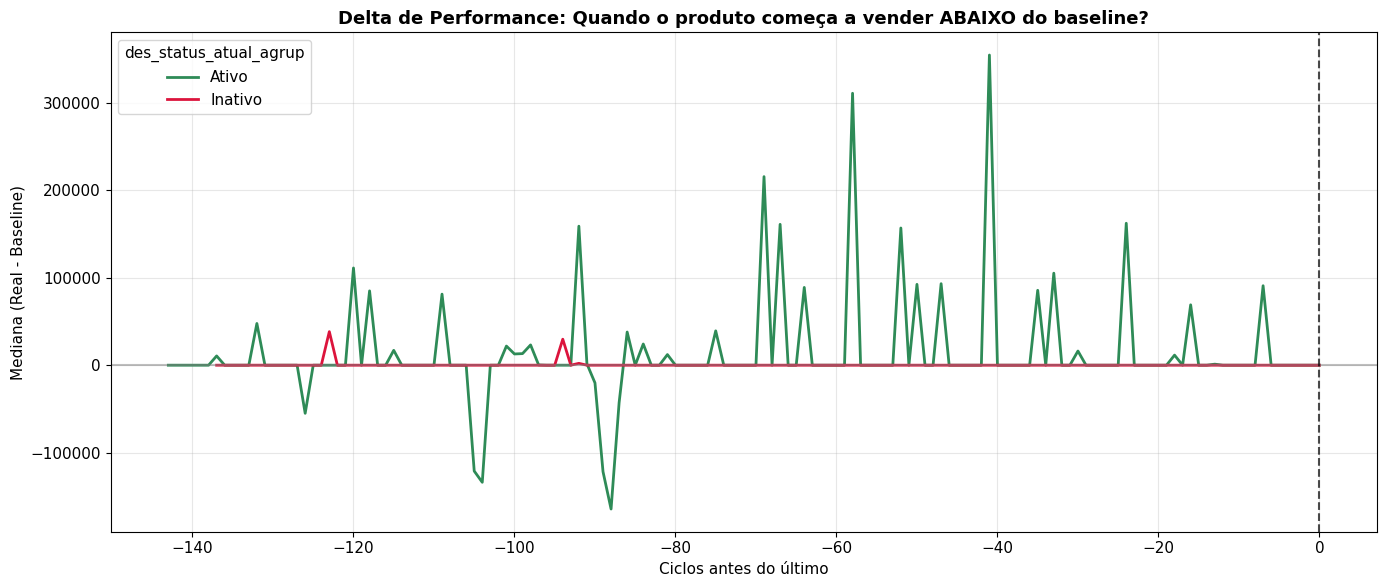

INSIGHT: Produtos Inativos cruzam o baseline (delta < 0) aproximadamente nan ciclos antes do fim.
→ Este é um possível 'ponto sem retorno' para ação proativa.


In [ ]:
# ----------------------------------------------------------
# 1.3 Delta de Performance (Real vs Baseline)
# ----------------------------------------------------------

print(f"{'='*60}")
print("1.3 DELTA DE PERFORMANCE (Real - Baseline)")
print(f"{'='*60}")

df["delta_performance"] = (
    df["ind_vlr_receita_real_dia_corrigido"] - df["ind_vlr_baseline_dia_corrigido"]
)

traj_delta = (
    df.groupby(["des_status_atual_agrup", "ciclos_antes_ultimo"])["delta_performance"]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=traj_delta,
    x="ciclos_antes_ultimo",
    y="delta_performance",
    hue="des_status_atual_agrup",
    palette={"Ativo": "seagreen", "Inativo": "crimson"},
    linewidth=2,
)
plt.axhline(0, linestyle="-", color="gray", alpha=0.5)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.fill_between(
    traj_delta[traj_delta["des_status_atual_agrup"] == "Inativo"]["ciclos_antes_ultimo"],
    traj_delta[traj_delta["des_status_atual_agrup"] == "Inativo"]["delta_performance"],
    0,
    where=(traj_delta[traj_delta["des_status_atual_agrup"] == "Inativo"]["delta_performance"] < 0),
    alpha=0.1,
    color="red",
)
plt.title("Delta de Performance: Quando o produto começa a vender ABAIXO do baseline?", fontsize=13, fontweight="bold")
plt.xlabel("Ciclos antes do último")
plt.ylabel("Mediana (Real - Baseline)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Encontrar o ciclo onde Inativos cruzam o zero
traj_inativo_delta = traj_delta[traj_delta["des_status_atual_agrup"] == "Inativo"]
cruzou_zero = traj_inativo_delta[traj_inativo_delta["delta_performance"] < 0]["ciclos_antes_ultimo"].max()
print(f"INSIGHT: Produtos Inativos cruzam o baseline (delta < 0) aproximadamente {abs(cruzou_zero)} ciclos antes do fim.")
print("→ Este é um possível 'ponto sem retorno' para ação proativa.")


1.4 RECEITA POR CPF (Ticket Médio)


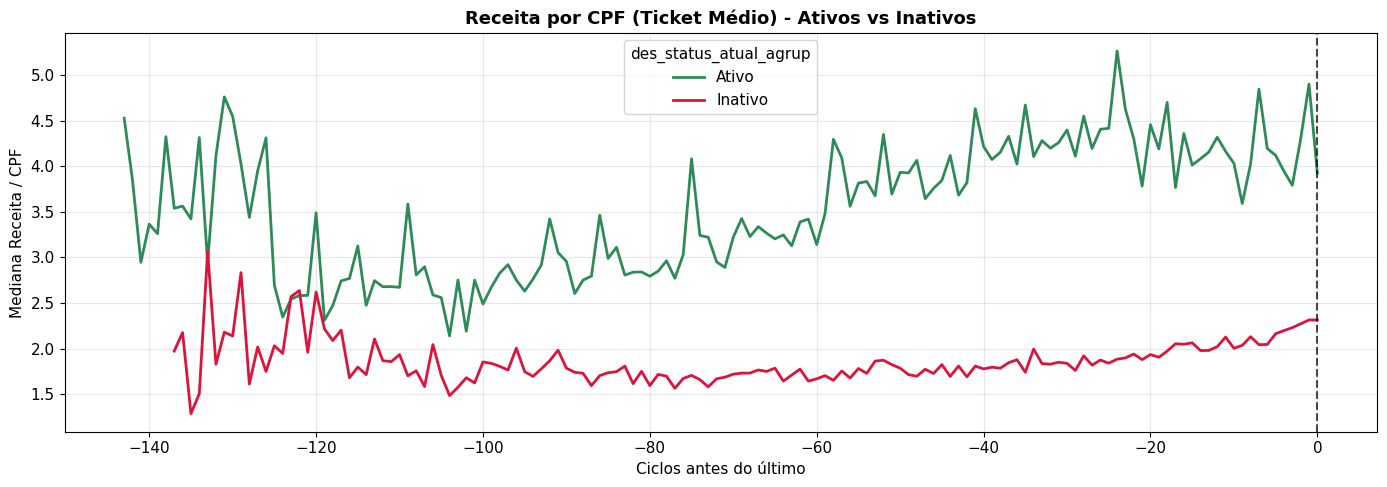

In [ ]:
# ----------------------------------------------------------
# 1.4 Receita por CPF (Ticket Médio)
# ----------------------------------------------------------

print(f"{'='*60}")
print("1.4 RECEITA POR CPF (Ticket Médio)")
print(f"{'='*60}")

df["receita_por_cpf"] = df["ind_vlr_receita_real_corrigido"] / df["ind_cpfs_total"].replace(0, np.nan)
df["receita_por_cpf"] = df["receita_por_cpf"].replace([np.inf, -np.inf], np.nan)

traj_ticket = (
    df.groupby(["des_status_atual_agrup", "ciclos_antes_ultimo"])["receita_por_cpf"]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.lineplot(
    data=traj_ticket,
    x="ciclos_antes_ultimo",
    y="receita_por_cpf",
    hue="des_status_atual_agrup",
    palette={"Ativo": "seagreen", "Inativo": "crimson"},
    linewidth=2,
)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.title("Receita por CPF (Ticket Médio) - Ativos vs Inativos", fontsize=13, fontweight="bold")
plt.xlabel("Ciclos antes do último")
plt.ylabel("Mediana Receita / CPF")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



############################################################
  PARTE 2: PADRÕES DE RUPTURA
############################################################
2.1 TAXA DE INCIDÊNCIA DE RUPTURA


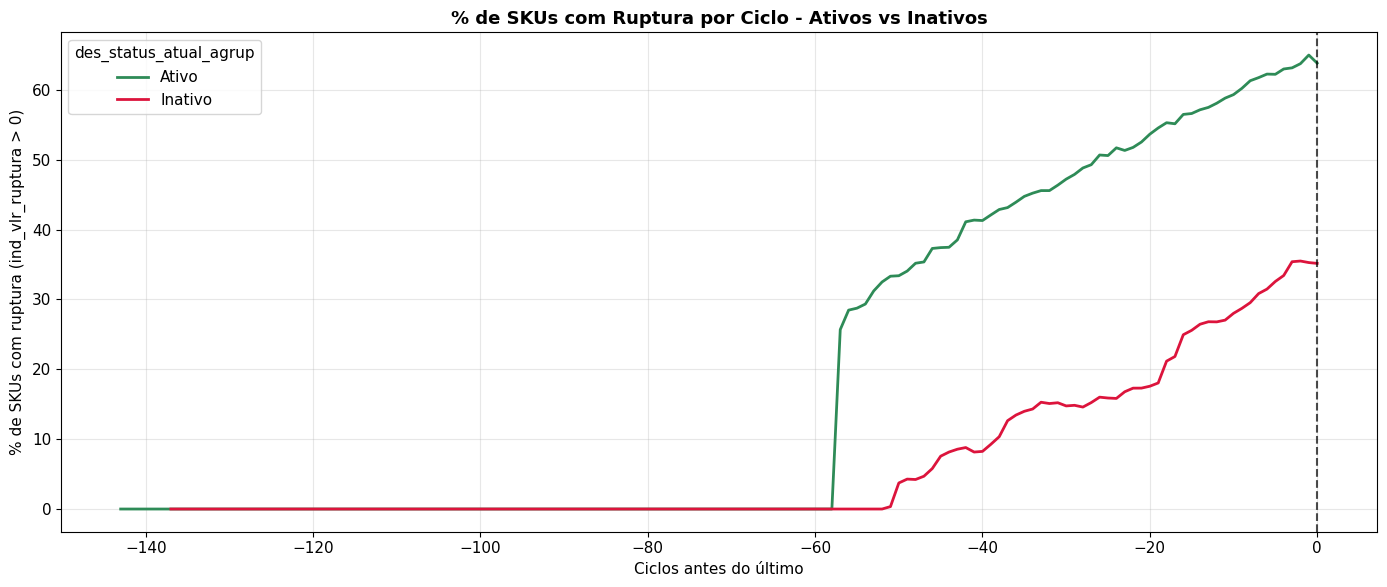

In [ ]:
# ============================================================
# ============================================================
#  PARTE 2: PADRÕES DE RUPTURA
# ============================================================
# ============================================================

print(f"{'#'*60}")
print("  PARTE 2: PADRÕES DE RUPTURA")
print(f"{'#'*60}")

# ----------------------------------------------------------
# 2.1 Taxa de incidência de ruptura ao longo do tempo
# ----------------------------------------------------------

print(f"{'='*60}")
print("2.1 TAXA DE INCIDÊNCIA DE RUPTURA")
print(f"{'='*60}")

df["flag_ruptura"] = (df["ind_vlr_ruptura"] > 0).astype(int)

taxa_ruptura = (
    df.groupby(["des_status_atual_agrup", "ciclos_antes_ultimo"])["flag_ruptura"]
    .mean()
    .reset_index()
)
taxa_ruptura["flag_ruptura"] = taxa_ruptura["flag_ruptura"] * 100

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=taxa_ruptura,
    x="ciclos_antes_ultimo",
    y="flag_ruptura",
    hue="des_status_atual_agrup",
    palette={"Ativo": "seagreen", "Inativo": "crimson"},
    linewidth=2,
)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.title("% de SKUs com Ruptura por Ciclo - Ativos vs Inativos", fontsize=13, fontweight="bold")
plt.xlabel("Ciclos antes do último")
plt.ylabel("% de SKUs com ruptura (ind_vlr_ruptura > 0)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


2.2 INTENSIDADE DA RUPTURA (valor)


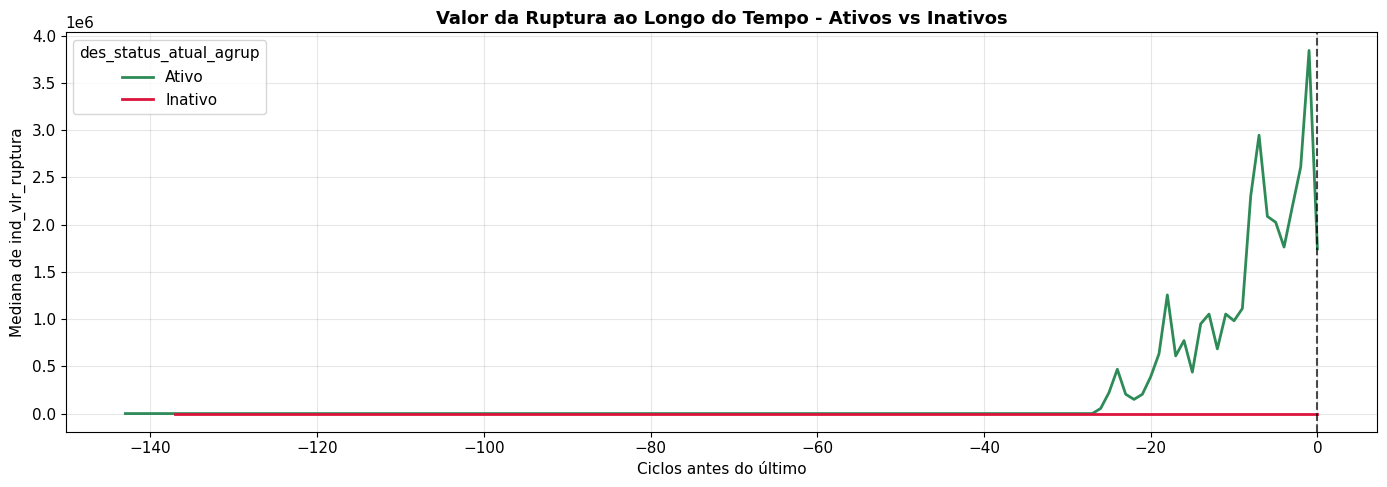

In [ ]:
# ----------------------------------------------------------
# 2.2 Intensidade da ruptura (valor)
# ----------------------------------------------------------

print(f"{'='*60}")
print("2.2 INTENSIDADE DA RUPTURA (valor)")
print(f"{'='*60}")



traj_ruptura_valor = (
    df.groupby(["des_status_atual_agrup", "ciclos_antes_ultimo"])["ind_vlr_ruptura"]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.lineplot(
    data=traj_ruptura_valor,
    x="ciclos_antes_ultimo",
    y="ind_vlr_ruptura",
    hue="des_status_atual_agrup",
    palette={"Ativo": "seagreen", "Inativo": "crimson"},
    linewidth=2,
)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.title("Valor da Ruptura ao Longo do Tempo - Ativos vs Inativos", fontsize=13, fontweight="bold")
plt.xlabel("Ciclos antes do último")
plt.ylabel("Mediana de ind_vlr_ruptura")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


2.3 RUPTURA vs QUEDA DE VENDAS


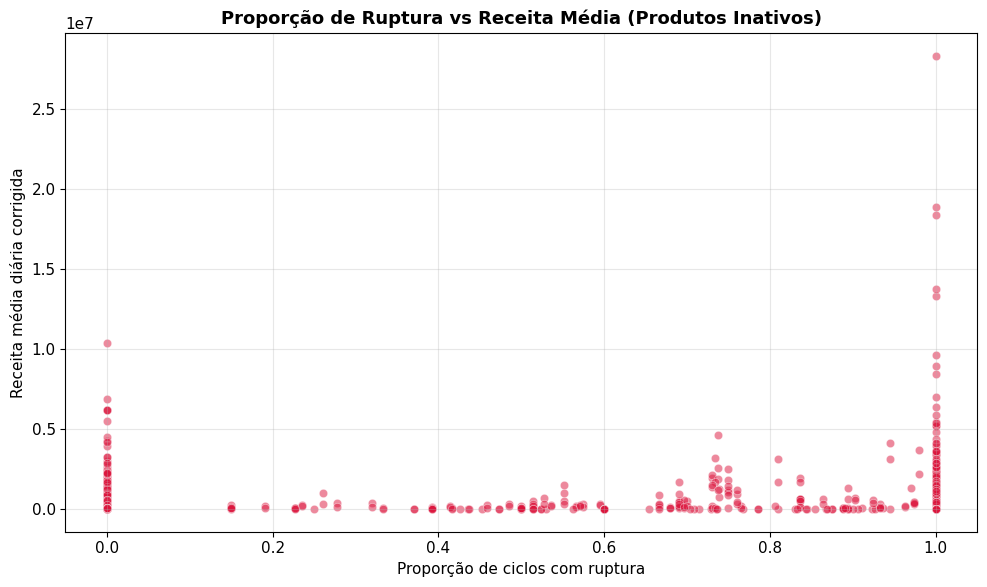

Correlação (Ruptura vs Receita): r = 0.2009, p-valor = 0.000000
INSIGHT: Relação positiva (ruptura pode indicar demanda não atendida)


In [ ]:
# ----------------------------------------------------------
# 2.3 Correlação entre ruptura e queda de vendas
# ----------------------------------------------------------

print(f"{'='*60}")
print("2.3 RUPTURA vs QUEDA DE VENDAS")
print(f"{'='*60}")

df_inativo["flag_ruptura"] = (df_inativo["ind_vlr_ruptura"] > 0).astype(int)


# Para Inativos: correlação entre ruptura acumulada e velocidade do declínio
ruptura_acum = (
    df_inativo.groupby("sk_produto_case")
    .agg(
        prop_ruptura=("flag_ruptura", "mean"),
        ruptura_media=("ind_vlr_ruptura", "mean"),
        receita_media=("ind_vlr_receita_real_dia_corrigido", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=ruptura_acum,
    x="prop_ruptura",
    y="receita_media",
    alpha=0.5,
    color="crimson",
)
plt.title("Proporção de Ruptura vs Receita Média (Produtos Inativos)", fontsize=13, fontweight="bold")
plt.xlabel("Proporção de ciclos com ruptura")
plt.ylabel("Receita média diária corrigida")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr, p_val = stats.pearsonr(
    ruptura_acum["prop_ruptura"].dropna(),
    ruptura_acum["receita_media"].dropna()
)
print(f"Correlação (Ruptura vs Receita): r = {corr:.4f}, p-valor = {p_val:.6f}")
print(f"INSIGHT: {'Ruptura está associada a menor receita' if corr < 0 else 'Relação positiva (ruptura pode indicar demanda não atendida)'}")


## 3. Expansão de Pontos de Vendas

3.1 EVOLUÇÃO DA BASE TOTAL DE PDVs


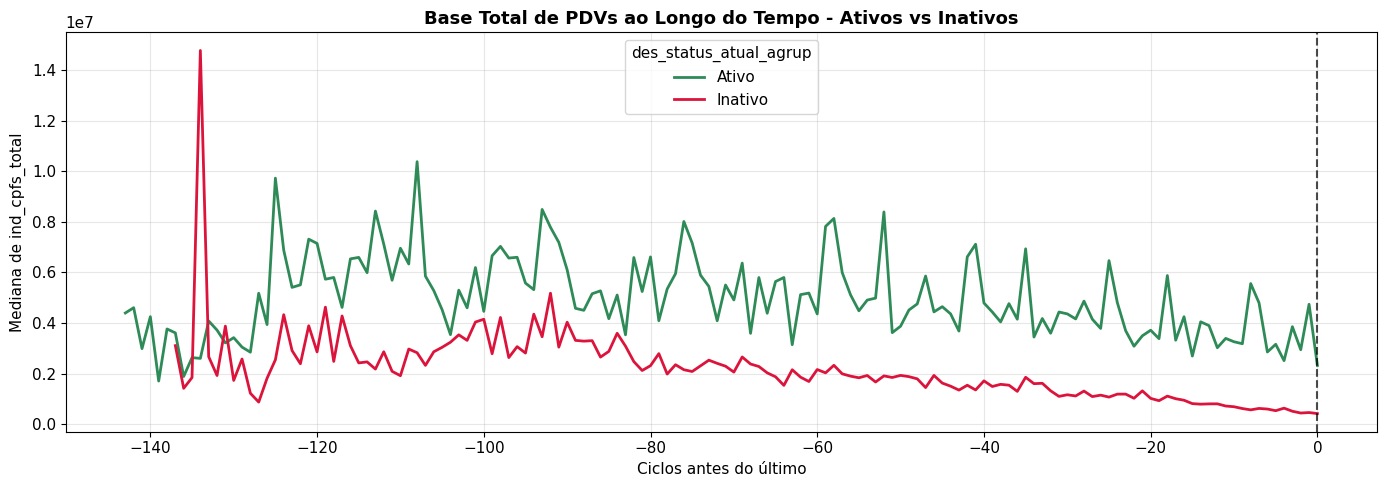

In [ ]:
# ----------------------------------------------------------
# 3.1 Evolução da base total de PDVs
# ----------------------------------------------------------

print(f"{'='*60}")
print("3.1 EVOLUÇÃO DA BASE TOTAL DE PDVs")
print(f"{'='*60}")

traj_cpfs = (
    df.groupby(["des_status_atual_agrup", "ciclos_antes_ultimo"])["ind_cpfs_total"]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.lineplot(
    data=traj_cpfs,
    x="ciclos_antes_ultimo",
    y="ind_cpfs_total",
    hue="des_status_atual_agrup",
    palette={"Ativo": "seagreen", "Inativo": "crimson"},
    linewidth=2,
)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.title("Base Total de PDVs ao Longo do Tempo - Ativos vs Inativos", fontsize=13, fontweight="bold")
plt.xlabel("Ciclos antes do último")
plt.ylabel("Mediana de ind_cpfs_total")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

3.2 EXPANSÃO DE PDVs NOVOS


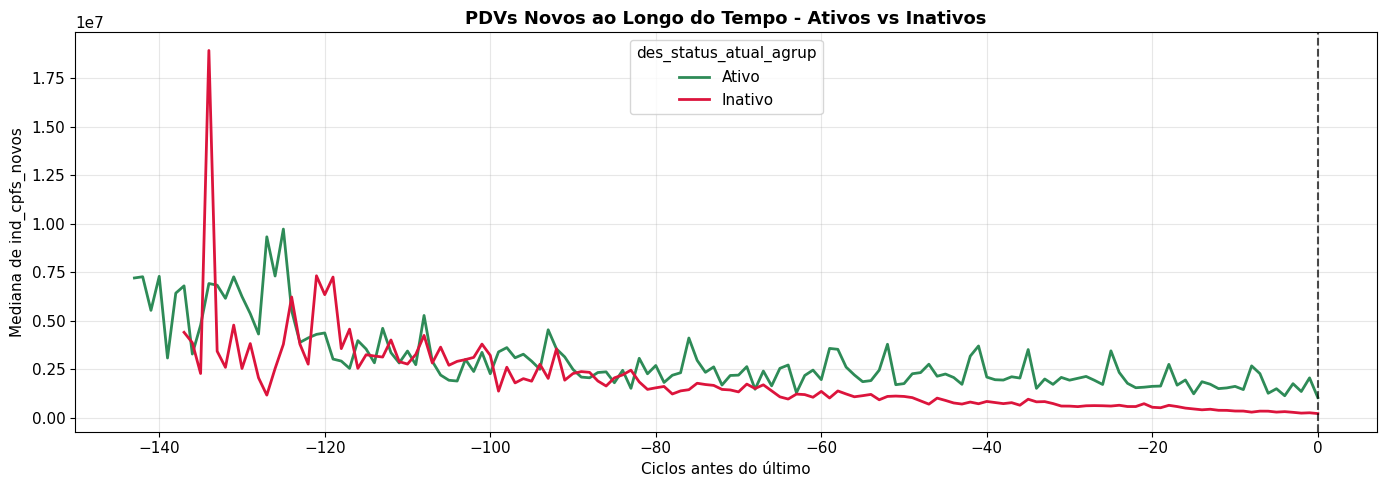

In [ ]:
# ----------------------------------------------------------
# 3.2 Expansão de PDVs novos
# ----------------------------------------------------------

print(f"{'='*60}")
print("3.2 EXPANSÃO DE PDVs NOVOS")
print(f"{'='*60}")

traj_novos = (
    df.groupby(["des_status_atual_agrup", "ciclos_antes_ultimo"])["ind_cpfs_novos"]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.lineplot(
    data=traj_novos,
    x="ciclos_antes_ultimo",
    y="ind_cpfs_novos",
    hue="des_status_atual_agrup",
    palette={"Ativo": "seagreen", "Inativo": "crimson"},
    linewidth=2,
)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.title("PDVs Novos ao Longo do Tempo - Ativos vs Inativos", fontsize=13, fontweight="bold")
plt.xlabel("Ciclos antes do último")
plt.ylabel("Mediana de ind_cpfs_novos")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

3.3 TAXA DE CONVERSÃO NO PDV


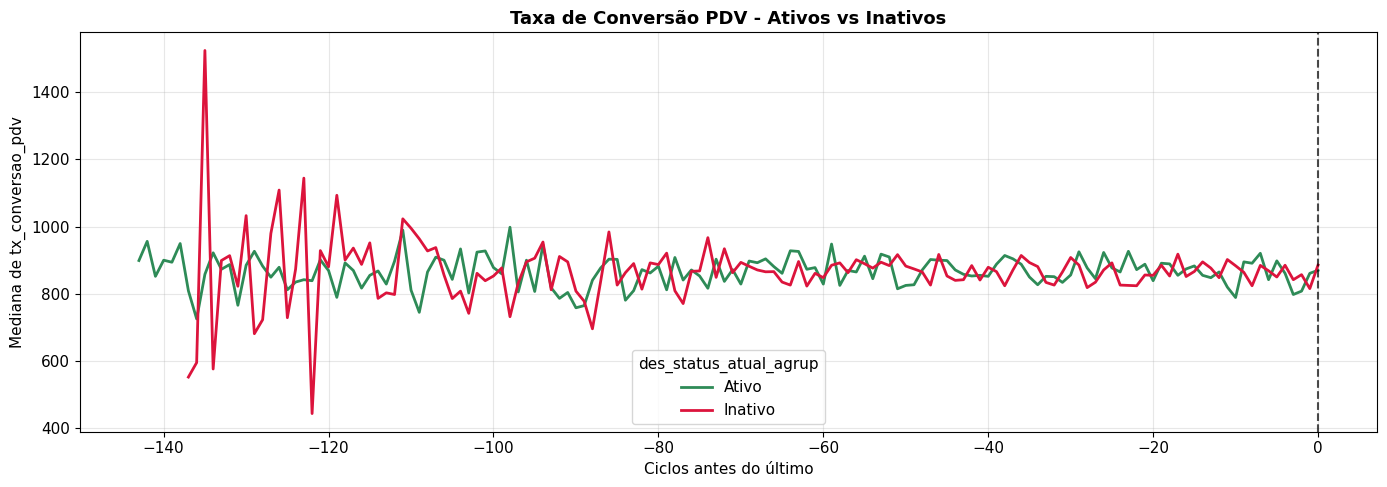

In [ ]:
# ----------------------------------------------------------
# 3.3 Taxa de conversão no PDV
# ----------------------------------------------------------

print(f"{'='*60}")
print("3.3 TAXA DE CONVERSÃO NO PDV")
print(f"{'='*60}")

if "tx_conversao_pdv" in df.columns:
    traj_conv = (
        df.groupby(["des_status_atual_agrup", "ciclos_antes_ultimo"])["tx_conversao_pdv"]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(14, 5))
    sns.lineplot(
        data=traj_conv,
        x="ciclos_antes_ultimo",
        y="tx_conversao_pdv",
        hue="des_status_atual_agrup",
        palette={"Ativo": "seagreen", "Inativo": "crimson"},
        linewidth=2,
    )
    plt.axvline(0, linestyle="--", color="black", alpha=0.7)
    plt.title("Taxa de Conversão PDV - Ativos vs Inativos", fontsize=13, fontweight="bold")
    plt.xlabel("Ciclos antes do último")
    plt.ylabel("Mediana de tx_conversao_pdv")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

3.4 PERDA DE PDVs vs QUEDA DE RECEITA


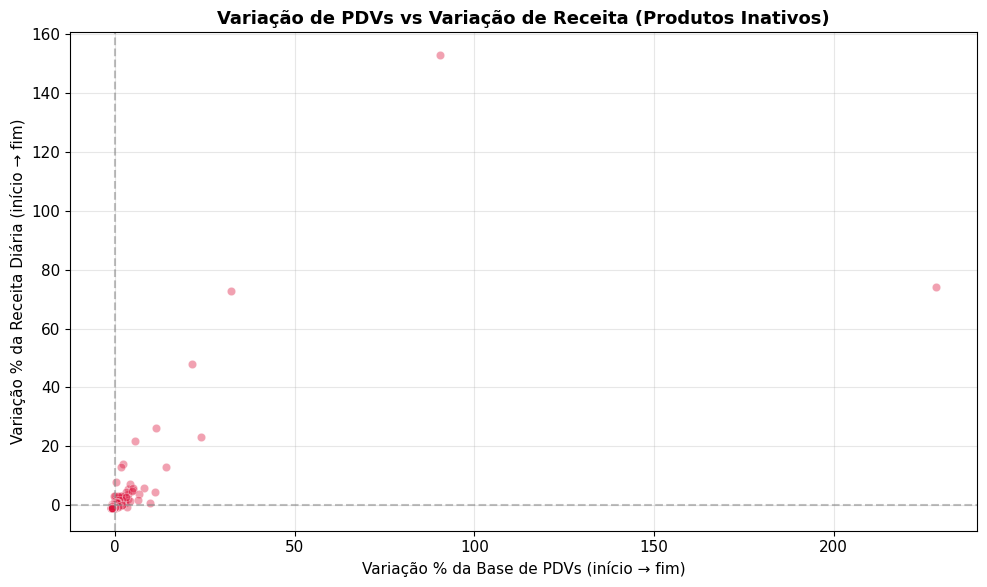

Correlação (Variação PDVs vs Variação Receita): r = 0.7171, p = 0.000000


In [ ]:
# ----------------------------------------------------------
# 3.4 Relação entre perda de PDVs e queda de receita
# ----------------------------------------------------------

print(f"{'='*60}")
print("3.4 PERDA DE PDVs vs QUEDA DE RECEITA")
print(f"{'='*60}")

# Variação de CPFs e Receita por produto (primeiros vs últimos ciclos)
def variacao_produto(grupo):
    if len(grupo) < 6:
        return pd.Series({"var_cpfs": np.nan, "var_receita": np.nan})
    meio = len(grupo) // 2
    cpf_inicio = grupo["ind_cpfs_total"].head(meio).mean()
    cpf_fim = grupo["ind_cpfs_total"].tail(meio).mean()
    rec_inicio = grupo["ind_vlr_receita_real_dia_corrigido"].head(meio).mean()
    rec_fim = grupo["ind_vlr_receita_real_dia_corrigido"].tail(meio).mean()

    var_cpfs = (cpf_fim - cpf_inicio) / abs(cpf_inicio) if cpf_inicio != 0 else 0
    var_receita = (rec_fim - rec_inicio) / abs(rec_inicio) if rec_inicio != 0 else 0
    return pd.Series({"var_cpfs": var_cpfs, "var_receita": var_receita})

variacoes = df_inativo.groupby("sk_produto_case").apply(variacao_produto).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=variacoes, x="var_cpfs", y="var_receita", alpha=0.4, color="crimson")
plt.axhline(0, linestyle="--", color="gray", alpha=0.5)
plt.axvline(0, linestyle="--", color="gray", alpha=0.5)
plt.title("Variação de PDVs vs Variação de Receita (Produtos Inativos)", fontsize=13, fontweight="bold")
plt.xlabel("Variação % da Base de PDVs (início → fim)")
plt.ylabel("Variação % da Receita Diária (início → fim)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_cpf, p_cpf = stats.pearsonr(
    variacoes["var_cpfs"].dropna(),
    variacoes["var_receita"].dropna()
)
print(f"Correlação (Variação PDVs vs Variação Receita): r = {corr_cpf:.4f}, p = {p_cpf:.6f}")



4.1 INVESTIMENTO EM MARKETING DIRETO


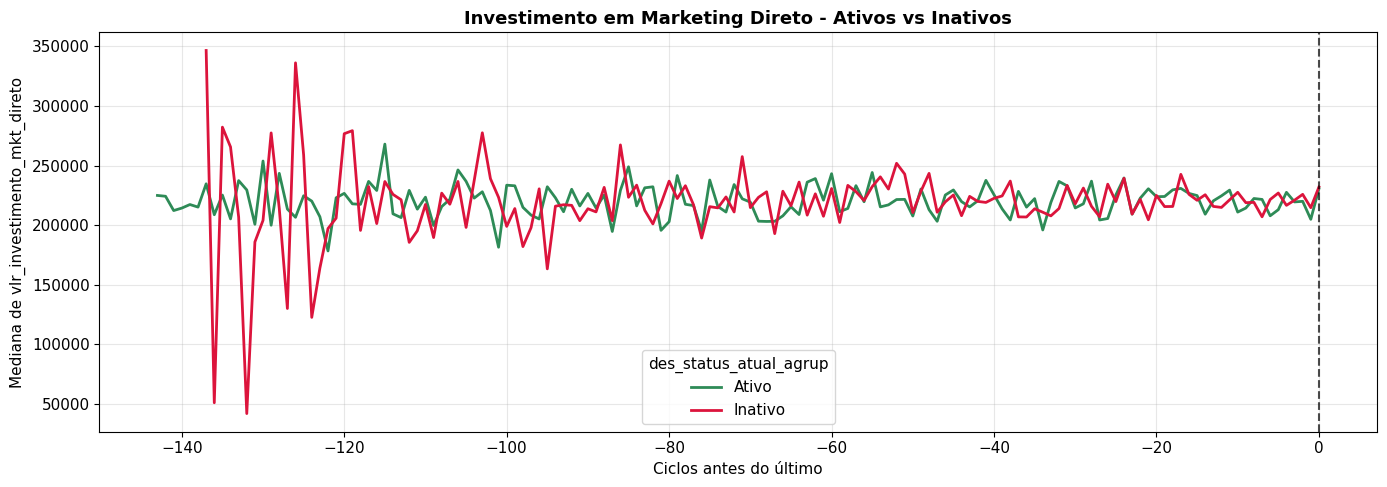

In [ ]:

# ----------------------------------------------------------
# 4.1 Marketing direto antes da inativação
# ----------------------------------------------------------

print(f"{'='*60}")
print("4.1 INVESTIMENTO EM MARKETING DIRETO")
print(f"{'='*60}")

if "vlr_investimento_mkt_direto" in df.columns:
    traj_mkt = (
        df.groupby(["des_status_atual_agrup", "ciclos_antes_ultimo"])["vlr_investimento_mkt_direto"]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(14, 5))
    sns.lineplot(
        data=traj_mkt,
        x="ciclos_antes_ultimo",
        y="vlr_investimento_mkt_direto",
        hue="des_status_atual_agrup",
        palette={"Ativo": "seagreen", "Inativo": "crimson"},
        linewidth=2,
    )
    plt.axvline(0, linestyle="--", color="black", alpha=0.7)
    plt.title("Investimento em Marketing Direto - Ativos vs Inativos", fontsize=13, fontweight="bold")
    plt.xlabel("Ciclos antes do último")
    plt.ylabel("Mediana de vlr_investimento_mkt_direto")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


############################################################
  PARTE 5: SÍNTESE DOS INSIGHTS
############################################################
5.1 PAINEL CONSOLIDADO: SINAIS DE ALERTA


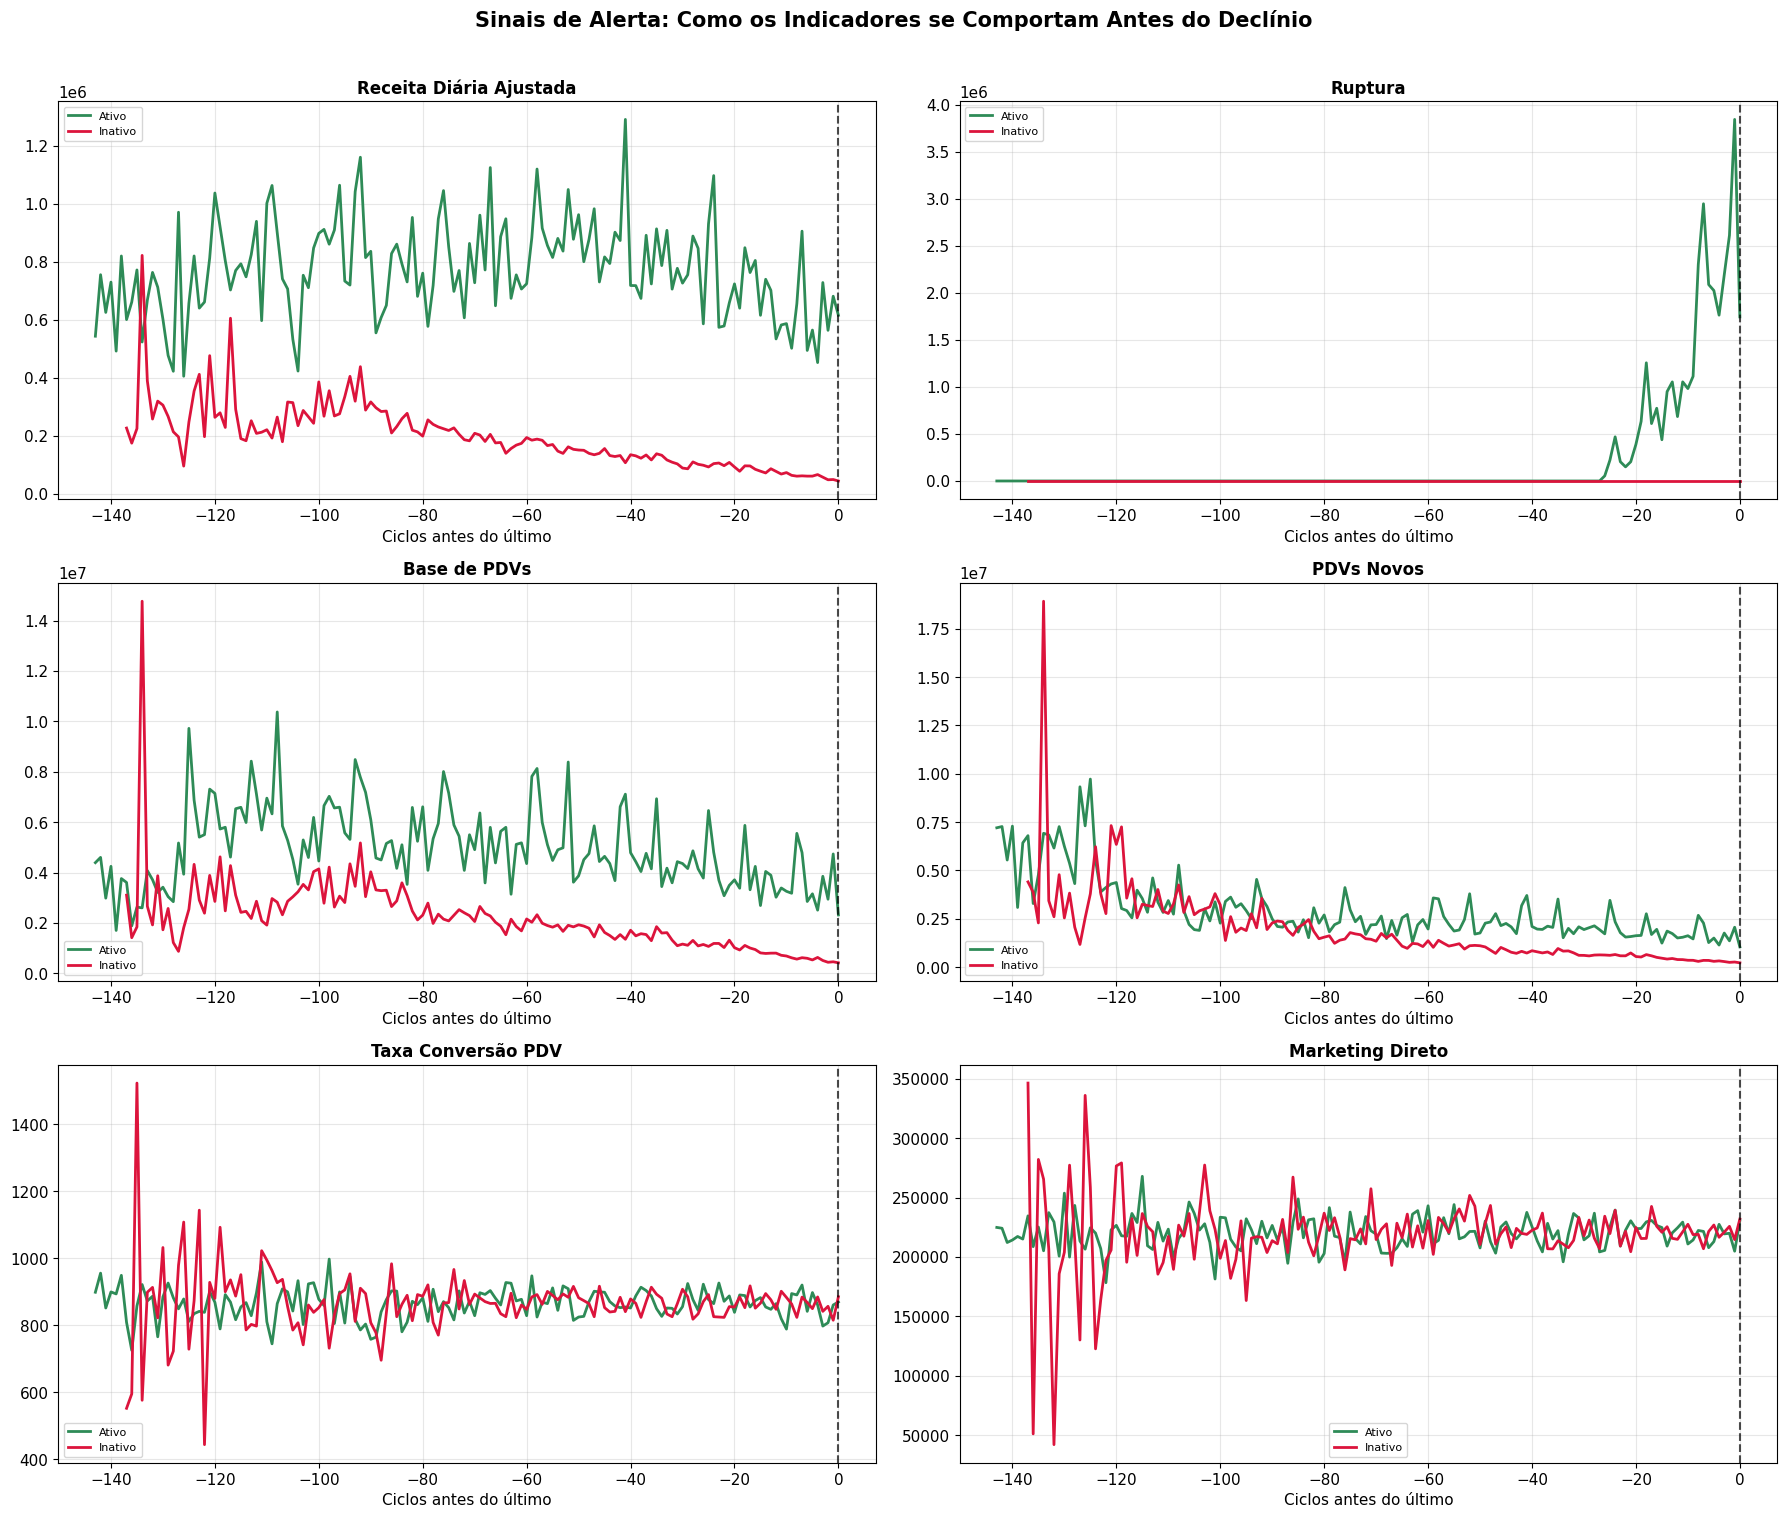

In [ ]:
print(f"{'#'*60}")
print("  PARTE 5: SÍNTESE DOS INSIGHTS")
print(f"{'#'*60}")

# ----------------------------------------------------------
# 5.1 Painel consolidado - Sinais de alerta
# ----------------------------------------------------------

print(f"{'='*60}")
print("5.1 PAINEL CONSOLIDADO: SINAIS DE ALERTA")
print(f"{'='*60}")

variaveis_painel = {
    "ind_vlr_receita_real_dia_corrigido": "Receita Diária Ajustada",
    "ind_vlr_ruptura": "Ruptura",
    "ind_cpfs_total": "Base de PDVs",
    "ind_cpfs_novos": "PDVs Novos",
}

if "tx_conversao_pdv" in df.columns:
    variaveis_painel["tx_conversao_pdv"] = "Taxa Conversão PDV"
if "vlr_investimento_mkt_direto" in df.columns:
    variaveis_painel["vlr_investimento_mkt_direto"] = "Marketing Direto"

n_vars = len(variaveis_painel)
n_rows = (n_vars + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, (var, titulo) in enumerate(variaveis_painel.items()):
    traj = (
        df.groupby(["des_status_atual_agrup", "ciclos_antes_ultimo"])[var]
        .median()
        .reset_index()
    )
    sns.lineplot(
        data=traj,
        x="ciclos_antes_ultimo",
        y=var,
        hue="des_status_atual_agrup",
        palette={"Ativo": "seagreen", "Inativo": "crimson"},
        linewidth=2,
        ax=axes[i],
    )
    axes[i].axvline(0, linestyle="--", color="black", alpha=0.7)
    axes[i].set_title(titulo, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Ciclos antes do último")
    axes[i].set_ylabel("")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Sinais de Alerta: Como os Indicadores se Comportam Antes do Declínio",
    fontsize=15, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()
